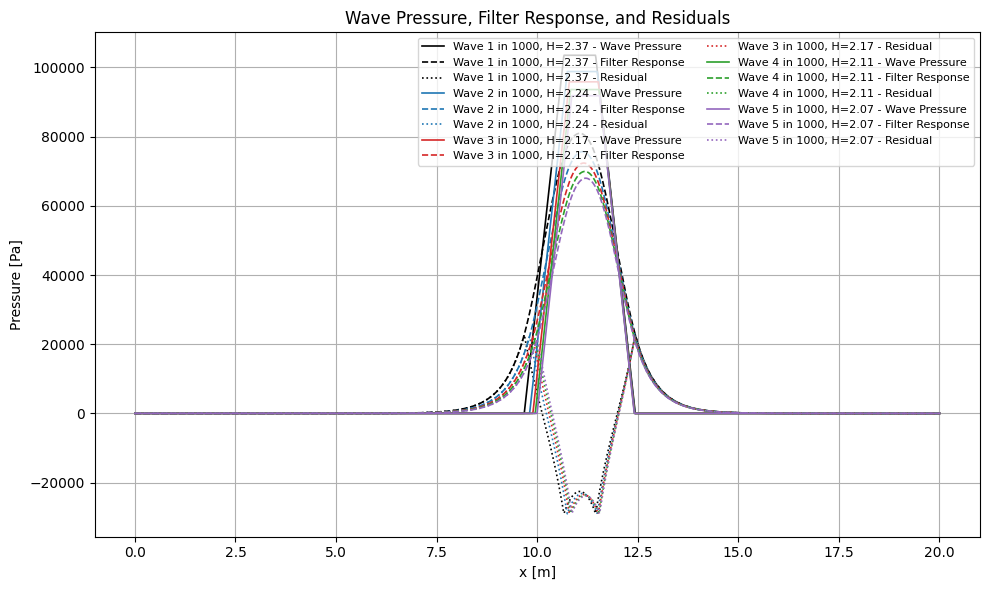

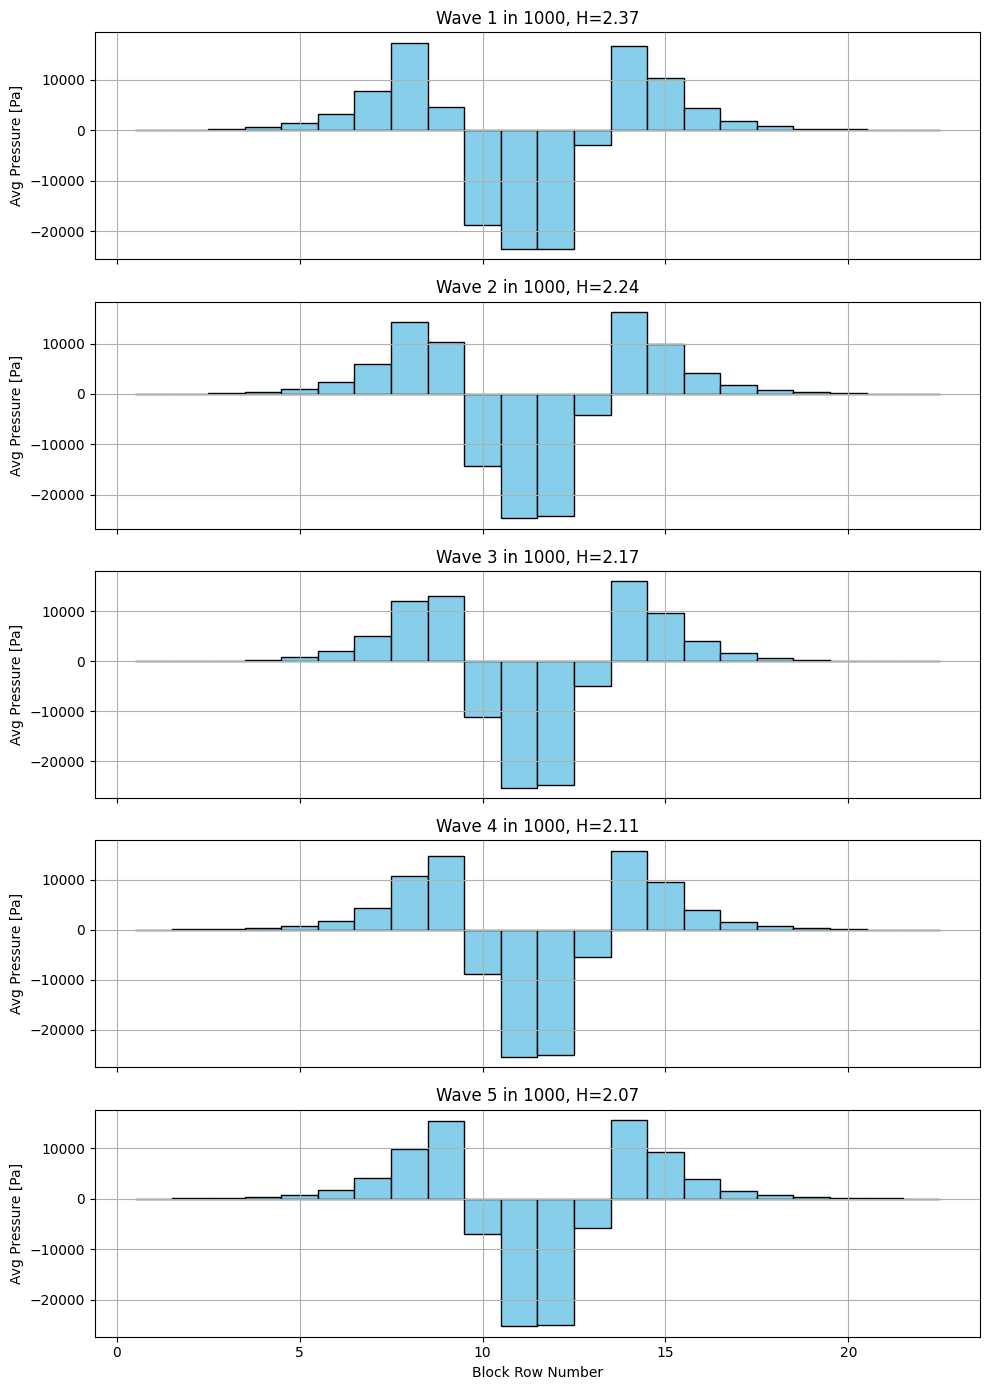

{'Wave 1 in 1000, H=2.37': [np.float64(37.102456641963364), np.float64(90.20238221696121), np.float64(219.8994092293784), np.float64(534.6128627237384), np.float64(1303.3031920981985), np.float64(3168.551716283618), np.float64(7724.43735289239), np.float64(17291.779124901863), np.float64(4520.9876859865435), np.float64(-18723.68250091792), np.float64(-23560.201973390627), np.float64(-23558.056467572966), np.float64(-2998.0352332433854), np.float64(16681.172481127593), np.float64(10296.181981840138), np.float64(4269.067216647819), np.float64(1755.972263840663), np.float64(720.2969839458943), np.float64(296.2758509635773), np.float64(121.53187334193707), np.float64(49.98904187033839), np.float64(20.505413388508966)], 'Wave 2 in 1000, H=2.24': [np.float64(28.322366530711424), np.float64(68.85648990160534), np.float64(167.86143645909752), np.float64(408.09970068045), np.float64(994.8837367685986), np.float64(2418.7315666478394), np.float64(5896.492193584298), np.float64(14335.375354951748)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.linalg import solve
import pandas as pd
from scipy.interpolate import interp1d
import os

# JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME 

job_name = 'Job-H-0_9'
Hs = 0.9

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.15
b = 0.1
k = 0.19
k_prime = 0.01
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)
H_wave_width = Hs

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Generate wave heights (Rayleigh) ---

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Initialize storage ---
block_pressures_per_wave = {}
residual_profiles = {}  
wave_pressures = {}
filter_responses = {}

# Loop through each wave

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    wave_pressures[wave_name] = p_vals
    filter_responses[wave_name] = phi_F
    residual_profiles[wave_name] = residual

    # Compute block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[f"Wave {i+1} in 1000, H={H_wave:.2f}"] = block_avg_pressures

# Plot histogram of block pressures for each wave
plt.figure(figsize=(10, 6))

colors = ["black", "tab:blue", "tab:red", "tab:green", "tab:purple"]
linestyles = ["-", "--", ":"]

for idx, wave_name in enumerate(wave_pressures.keys()):
    color = colors[idx % len(colors)]
    plt.plot(x, wave_pressures[wave_name],
             linestyle=linestyles[0],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Wave Pressure")

    plt.plot(x, filter_responses[wave_name],
             linestyle=linestyles[1],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Filter Response")

    plt.plot(x, residual_profiles[wave_name],
             linestyle=linestyles[2],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Residual")

plt.xlabel("x [m]")
plt.ylabel("Pressure [Pa]")
plt.title("Wave Pressure, Filter Response, and Residuals")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot histogram of block pressures for each wave
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for i, (wave_name, pressures) in enumerate(block_pressures_per_wave.items()):
    axs[i].bar(np.arange(1, 23), pressures, color='skyblue', width=1, edgecolor='black')
    axs[i].set_ylabel("Avg Pressure [Pa]")
    axs[i].set_title(f"{wave_name}")
    axs[i].grid(True)

axs[-1].set_xlabel("Block Row Number")
plt.tight_layout()
plt.show()

print(block_pressures_per_wave)

# -----------------------------------------------------------------------------------------------------------------



